top 5 rows

In [0]:
# Import necessary libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the file path. Adjust this path if your file is located elsewhere.
file_path = "/Volumes/workspace/default/jaya/netflix_updated.csv"
df = pd.read_csv(file_path)

print("--- Data Loaded ---")
print(f"Total rows: {len(df)}")
print("First 5 rows:")
display(df.head())
print("\nData Info:")
df.info()

--- Data Loaded ---
Total rows: 8807
First 5 rows:


show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,title_length,is_movie
s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable.",20,1
s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshabalala, Getmore Sithole, Cindy Mahlangu, Ryle De Morny, Greteli Fincham, Sello Maake Ka-Ncube, Odwa Gwanya, Mekaila Mathys, Sandi Schultz, Duane Williams, Shamilla Miller, Patrick Mofokeng",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her sister who was abducted at birth.",13,0
s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert Van Rampelberg, Bakary Diombera",Unknown,2021-09-24,2021,TV-MA,1 Seasons,"Crime TV Shows, International TV Shows, TV Action & Adventure","To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robbers are pulled into a violent and deadly turf war.",9,0
s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Seasons,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice Center in New Orleans on this gritty reality series.",21,0
s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam Khan, Ahsaas Channa, Revathi Pillai, Urvi Singh, Arun Kumar",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV Comedies","In a city of coaching centers known to train India’s finest collegiate minds, an earnest but unexceptional student and his friends navigate campus life.",12,0



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      8807 non-null   object
 4   cast          8807 non-null   object
 5   country       8807 non-null   object
 6   date_added    8807 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8807 non-null   object
 9   duration      8807 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
 12  title_length  8807 non-null   int64 
 13  is_movie      8807 non-null   int64 
dtypes: int64(3), object(11)
memory usage: 963.4+ KB


preprocessing

In [0]:
# 1. Feature Selection
features = ['release_year', 'title_length', 'is_movie', 'rating']
data = df[features].copy()

# 2. Preprocessing Pipeline
numerical_features = ['release_year', 'title_length']
categorical_features = ['rating']
binary_features = ['is_movie'] # Keep as is, no scaling or encoding needed

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        # Scale numerical features (Release Year and Title Length)
        ('num', StandardScaler(), numerical_features),
        # One-Hot Encode the 'rating' feature
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        # Keep the 'is_movie' (binary) feature as is
        ('bin', 'passthrough', binary_features)
    ],
    remainder='drop' # Drop any other columns
)

# Apply the transformations
X_scaled = preprocessor.fit_transform(data)

# Create a DataFrame of the scaled features for easier inspection and column name retrieval
feature_names = numerical_features + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)) + binary_features
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)

print("--- Preprocessed Data (Scaled and Encoded) ---")
display(X_scaled_df.head())

--- Preprocessed Data (Scaled and Encoded) ---


release_year,title_length,rating_66 min,rating_74 min,rating_84 min,rating_G,rating_NC-17,rating_NR,rating_PG,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV,rating_UR,is_movie
0.6599304775080349,0.21394746066938303,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
0.7733244432755346,-0.4445471475586144,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
0.7733244432755346,-0.8208297808317558,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
0.7733244432755346,0.3080181189876684,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
0.7733244432755346,-0.5386178058768998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


elbow method

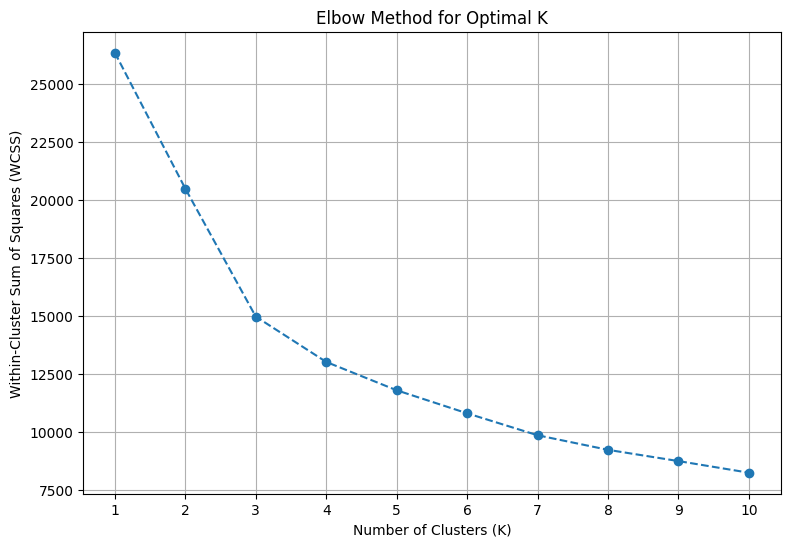

--- Elbow Plot Generated ---
Visual inspection suggests K=4 or K=5 as a reasonable elbow point.


In [0]:
# --- Elbow Method for Optimal K ---
wcss = []
k_range = range(1, 11)

# Fit KMeans for K=1 to K=10
for k in k_range:
    # Set n_init to 10 for consistency and better convergence
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(9, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.xticks(k_range)
plt.show() # Databricks/Jupyter will display the plot

print("--- Elbow Plot Generated ---")
print("Visual inspection suggests K=4 or K=5 as a reasonable elbow point.")

summary of cluster

In [0]:
# --- Final K-Means Clustering with K=4 ---
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Get the cluster centers (centroids)
centroids_df = pd.DataFrame(kmeans.cluster_centers_, columns=X_scaled_df.columns)

# --- Inverse Transform Centroids for Interpretation ---
# Re-fit the StandardScaler to the original numerical features to get mean/std
scaler = StandardScaler()
scaler.fit(df[numerical_features])
mean_values = scaler.mean_
std_values = scaler.var_ ** 0.5 # Calculate std from variance

# Inverse transform the scaled numerical features in the centroids
for i, col in enumerate(numerical_features):
    col_scaled_index = X_scaled_df.columns.get_loc(col)
    # Inverse formula: original = scaled * std + mean
    centroids_df[col] = centroids_df[col].apply(lambda x: x * std_values[i] + mean_values[i])

# Summarize the clusters using the original dataframe with cluster labels
cluster_summary = df.groupby('Cluster').agg({
    'show_id': 'count',
    'is_movie': 'mean',
    'rating': lambda x: x.mode()[0]
}).reset_index()

cluster_summary.rename(columns={'show_id': 'Count', 'is_movie': 'Movie_Proportion', 'rating': 'Most_Frequent_Rating'}, inplace=True)
cluster_summary['Movie_Proportion'] = (cluster_summary['Movie_Proportion'] * 100).round(1).astype(str) + '%'

# Merge average release year and title length from inverse-transformed centroids
cluster_summary['Avg_Release_Year'] = centroids_df['release_year'].round(0).astype(int)
cluster_summary['Avg_Title_Length'] = centroids_df['title_length'].round(1)

print("--- Cluster Summary (Interpretable) ---")
display(cluster_summary)

print("\n--- Centroid Data (Full Scaled Values) ---")
display(centroids_df)

--- Cluster Summary (Interpretable) ---


Cluster,Count,Movie_Proportion,Most_Frequent_Rating,Avg_Release_Year,Avg_Title_Length
0,2500,60.7%,TV-MA,2017,12.8
1,3882,70.4%,TV-14,2015,13.3
2,1841,73.3%,TV-MA,2016,34.0
3,584,90.9%,TV-14,1988,16.6



--- Centroid Data (Full Scaled Values) ---


release_year,title_length,rating_66 min,rating_74 min,rating_84 min,rating_G,rating_NC-17,rating_NR,rating_PG,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV,rating_UR,is_movie
2017.2784000000001,12.81879999999996,-2.6698478497455547E-18,-2.6698478497455547E-18,-2.6698478497455547E-18,-3.2959746043559335E-17,-3.144186300207963E-18,5.204170427930421E-18,9.922618282587337E-16,4.579669976578771E-16,-5.273559366969494E-16,2.831068712794149E-15,-2.3245294578089215E-16,0.9999999999999938,-1.0408340855860843E-15,1.6653345369377348E-16,-9.992007221626409E-16,-6.288372600415926E-18,-3.144186300207963E-18,0.6071999999999975
2015.11695002576,13.332560535806188,-3.550762114890027E-18,2.5759917568265664E-4,2.5759917568265566E-4,0.0038639876352395833,5.151983513652961E-4,0.015713549716640997,0.04224626481195297,0.0899021123132414,0.15275631117980434,0.4296754250386429,0.031942297784646904,-6.328271240363392E-15,0.14966512107161126,0.0445646573930964,0.0378670788253479,5.151983513652879E-4,2.5759917568263756E-4,0.7040185471406488
2016.439978272678,34.01195002715896,5.431830526887697E-4,-1.7753810574450135E-18,-1.7753810574450135E-18,0.004345464421510074,5.431830526887655E-4,0.006518196632264996,0.03910917979359045,0.02987506789788128,0.03910917979358994,0.19174361759912997,0.04562737642585536,0.35143943508962516,0.12112982074959248,0.07170016295491621,0.09560021727321943,0.0021727322107550373,5.431830526887574E-4,0.7327539380771319
1987.5667808219177,16.59246575342466,-2.0328790734103208E-19,-2.0328790734103208E-19,-2.0328790734103208E-19,0.030821917808219048,-7.047314121155779E-19,0.011986301369863037,0.0873287671232878,0.14726027397260244,0.22945205479452,0.23801369863013727,0.02054794520547943,0.10958904109588857,0.10102739726027414,0.003424657534246575,0.018835616438356285,-1.4094628242311558E-18,0.001712328767123302,0.9092465753424652


visualization

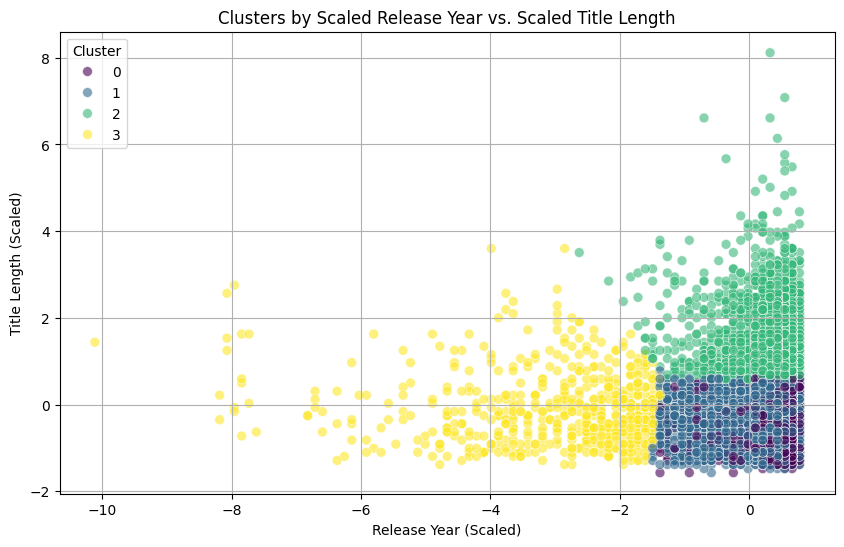

In [0]:
# --- Visualization: Plotting the clusters by Release Year and Title Length ---
plt.figure(figsize=(10, 6))

# Use the scaled version of the data for a meaningful visualization with equal weighting
df['release_year_scaled'] = X_scaled_df['release_year']
df['title_length_scaled'] = X_scaled_df['title_length']

sns.scatterplot(
    x='release_year_scaled',
    y='title_length_scaled',
    hue='Cluster',
    data=df,
    palette='viridis',
    s=50,
    alpha=0.6
)

plt.title('Clusters by Scaled Release Year vs. Scaled Title Length')
plt.xlabel('Release Year (Scaled)')
plt.ylabel('Title Length (Scaled)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [0]:
import pandas as pd

# Load both datasets
df_updated = pd.read_csv("/Volumes/workspace/default/jaya/netflix_updated.csv")
df_cleaned = pd.read_csv("/Volumes/workspace/default/jaya/netflix_cleaned.csv")

# Use 'show_id' as the merge key
merge_key = 'show_id'

# Identify columns in 'cleaned' that might be missing in 'updated' (all are present in this case, but this is the safe approach)
# Note: 'title_length' and 'is_movie' are only in 'updated', which is fine.

# The merge operation ensures all columns and all rows are aligned.
# We'll merge the 'cleaned' data into 'updated' to pick up any potentially missing original columns.
df_merged = pd.merge(df_updated, df_cleaned.drop(columns=['type', 'title', 'release_year', 'rating', 'description']),
                     on=merge_key, how='left', suffixes=('_updated', '_cleaned'))

# Check for duplicated columns (e.g., 'country_updated', 'country_cleaned') and consolidate
for col in df_merged.columns:
    if col.endswith('_cleaned'):
        original_col = col.replace('_cleaned', '')
        # Drop the cleaned version if the updated version is good (assuming updated is the primary source)
        df_merged.drop(columns=[col], inplace=True)
    elif col.endswith('_updated'):
        # Rename the updated column back to its original name
        df_merged.rename(columns={col: col.replace('_updated', '')}, inplace=True)

# Final check and save
print("--- Final Merged Dataset Columns ---")
print(df_merged.columns.tolist())
print("\nFinal Merged Dataset Head:")
display(df_merged.head())

# Save the final consolidated dataset
df_merged.to_csv('netflix_final_consolidated.csv', index=False)

--- Final Merged Dataset Columns ---
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'title_length', 'is_movie']

Final Merged Dataset Head:


show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,title_length,is_movie
s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable.",20,1
s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshabalala, Getmore Sithole, Cindy Mahlangu, Ryle De Morny, Greteli Fincham, Sello Maake Ka-Ncube, Odwa Gwanya, Mekaila Mathys, Sandi Schultz, Duane Williams, Shamilla Miller, Patrick Mofokeng",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her sister who was abducted at birth.",13,0
s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert Van Rampelberg, Bakary Diombera",Unknown,2021-09-24,2021,TV-MA,1 Seasons,"Crime TV Shows, International TV Shows, TV Action & Adventure","To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robbers are pulled into a violent and deadly turf war.",9,0
s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Seasons,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice Center in New Orleans on this gritty reality series.",21,0
s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam Khan, Ahsaas Channa, Revathi Pillai, Urvi Singh, Arun Kumar",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV Comedies","In a city of coaching centers known to train India’s finest collegiate minds, an earnest but unexceptional student and his friends navigate campus life.",12,0


--- Cluster Summary (K=4) ---


Cluster,Count,Movie_Proportion,Most_Frequent_Rating,Avg_Release_Year,Avg_Title_Length
0,2500,60.7%,TV-MA,2017,12.8
1,3882,70.4%,TV-14,2015,13.3
2,1841,73.3%,TV-MA,2016,34.0
3,584,90.9%,TV-14,1988,16.6


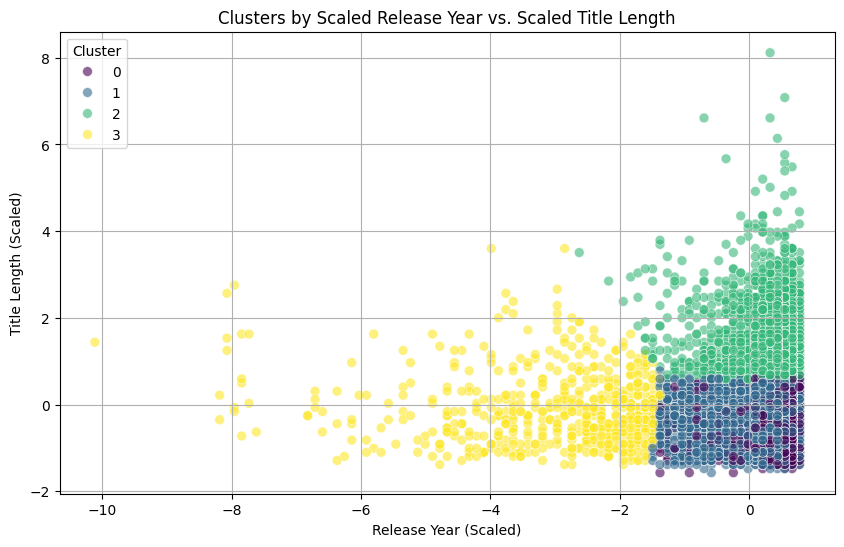

In [0]:
# --- Final K-Means Clustering with K=4 (based on typical elbow point) ---
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Get Centroids and Inverse Transform for Interpretation (using original numerical values)
scaler = StandardScaler()
scaler.fit(df[numerical_features])
mean_values = scaler.mean_
std_values = scaler.var_ ** 0.5
centroids_df = pd.DataFrame(kmeans.cluster_centers_, columns=X_scaled_df.columns)

# Inverse transform the numerical features in the centroids
for i, col in enumerate(numerical_features):
    col_scaled_index = X_scaled_df.columns.get_loc(col)
    centroids_df[col] = centroids_df[col].apply(lambda x: x * std_values[i] + mean_values[i])

# Summarize the clusters
cluster_summary = df.groupby('Cluster').agg(
    Count=('show_id', 'count'),
    Movie_Proportion=('is_movie', 'mean'),
    Most_Frequent_Rating=('rating', lambda x: x.mode()[0])
).reset_index()

cluster_summary['Movie_Proportion'] = (cluster_summary['Movie_Proportion'] * 100).round(1).astype(str) + '%'

# Merge interpreted numerical averages
cluster_summary['Avg_Release_Year'] = centroids_df['release_year'].round(0).astype(int)
cluster_summary['Avg_Title_Length'] = centroids_df['title_length'].round(1)

print("--- Cluster Summary (K=4) ---")
display(cluster_summary)

# --- Visualization ---
# Use the scaled features from X_scaled_df for plotting
df['release_year_scaled'] = X_scaled_df['release_year']
df['title_length_scaled'] = X_scaled_df['title_length']

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='release_year_scaled',
    y='title_length_scaled',
    hue='Cluster',
    data=df,
    palette='viridis',
    s=50,
    alpha=0.6
)
plt.title('Clusters by Scaled Release Year vs. Scaled Title Length')
plt.xlabel('Release Year (Scaled)')
plt.ylabel('Title Length (Scaled)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

k means clustering k=4

Number of components after PCA (retaining 90% variance): 19

--- K-Means Cluster Summary (K=4) ---
 Cluster  Count  Avg_Release_Year  Avg_Title_Length Most_Frequent_Rating Most_Frequent_Type  Avg_Movie_Duration (min)  Avg_TV_Duration (Seasons)            Top_Genre_1              Top_Genre_2     Top_Genre_3
       0   2629            2016.9              16.6                TV-MA            TV Show                       0.0                        1.8 International TV Shows                TV Dramas     TV Comedies
       1   4197            2015.3              13.0                TV-MA              Movie                     104.9                        0.0   International Movies                   Dramas        Comedies
       2   1431            2016.3              34.1                TV-MA              Movie                      77.3                        1.1          Documentaries Children & Family Movies Stand-Up Comedy
       3    550            1987.1              16.2              

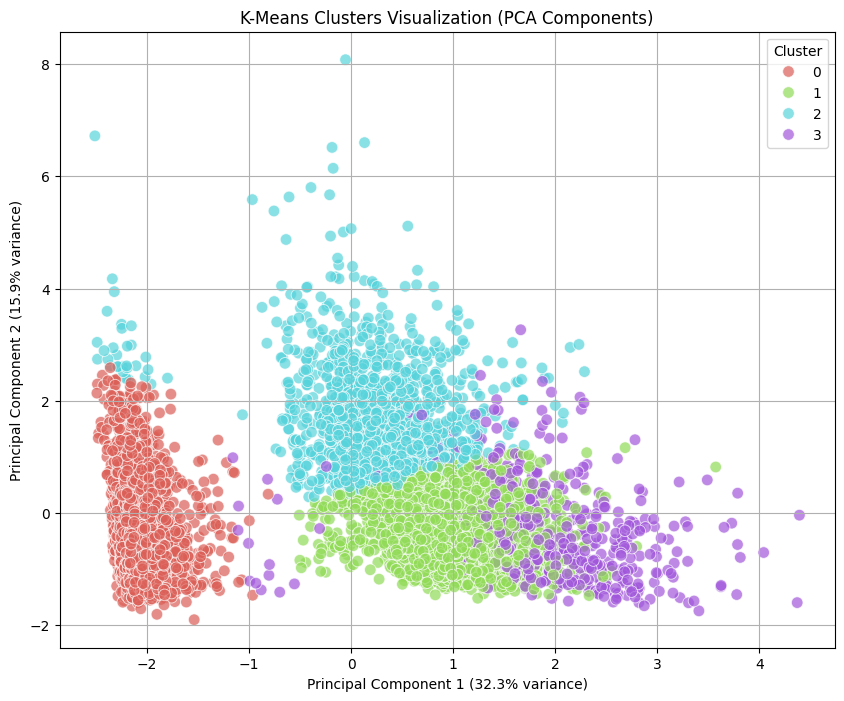

In [0]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Data Loading and Initial Feature Engineering ---

# Load the updated dataset
df = pd.read_csv("/Volumes/workspace/default/jaya/netflix_updated.csv")

# Feature Engineering: Duration value and type (Movie vs TV Show/Seasons)
def clean_and_categorize_duration(duration):
    """Extracts duration value and type (min/Seasons)."""
    if pd.isna(duration):
        return 0.0, 'Unknown'
    parts = str(duration).split()
    if len(parts) == 2:
        value = float(parts[0])
        unit = parts[1]
        if unit in ['min', 'mins']:
            return value, 'Movie_Min'
        elif 'Season' in unit:
            return value, 'TV_Seasons'
    return 0.0, 'Unknown'

# Apply the duration function to create two new columns
df[['Duration_Value', 'Duration_Type']] = df['duration'].apply(lambda x: pd.Series(clean_and_categorize_duration(x)))

# --- 2. Genre One-Hot Encoding and Data Prep ---

# Get unique genres (for genre OHE column names)
df_genres = df['listed_in'].str.split(', ', expand=True).stack().reset_index(level=1, drop=True).rename('genre')
all_genres = sorted(df_genres.dropna().unique().tolist())

# Create the Genre One-Hot Encoding matrix (show_id vs genre)
genre_ohe = df.groupby('show_id')['listed_in'].apply(lambda x: pd.Series(1, index=x.iloc[0].split(', '))).unstack(fill_value=0)
genre_ohe.columns.name = None
genre_ohe = genre_ohe.rename(columns=lambda x: x.strip())

# Merge the genre OHE matrix back to the main dataframe
df_clust = df.merge(genre_ohe, on='show_id', how='left')

# Drop columns not needed for clustering or analysis interpretation
df_clust.drop(columns=['listed_in', 'duration', 'director', 'cast', 'country', 'date_added', 'description', 'title', 'show_id'], inplace=True)

# Final Feature Selection
numerical_features = ['Duration_Value', 'release_year', 'title_length']
categorical_features = ['rating', 'Duration_Type', 'type']
genre_features = [col for col in genre_ohe.columns if col in df_clust.columns]

# Fill NaNs from OHE process and drop rows with missing categorical data
df_clust[genre_features] = df_clust[genre_features].fillna(0).astype(int)
df_clust.dropna(subset=categorical_features + numerical_features, inplace=True)

# --- 3. Preprocessing Pipeline ---

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('genre', 'passthrough', genre_features)
    ],
    remainder='drop'
)

# Apply preprocessing
X_scaled = preprocessor.fit_transform(df_clust)

# --- 4. Dimensionality Reduction (PCA) ---

# Reduce the high-dimensional feature set to components retaining 90% of the variance
pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Number of components after PCA (retaining 90% variance): {pca.n_components_}")

# --- 5. K-Means Clustering (Using K=4) ---

optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca)

# Assign cluster labels back to the dataframe
df_clust['Cluster'] = cluster_labels
df_clust = df_clust.reset_index(drop=True)

# --- 6. Cluster Analysis and Interpretation ---

# 6a. Create the base summary table
cluster_summary = df_clust.groupby('Cluster').agg(
    Count=('Duration_Value', 'count'),
    Avg_Release_Year=('release_year', 'mean'),
    Avg_Title_Length=('title_length', 'mean'),
    Most_Frequent_Rating=('rating', lambda x: x.mode()[0]),
    Most_Frequent_Type=('type', lambda x: x.mode()[0]),
).reset_index()

# 6b. Calculate average duration, separated by type
duration_means = df_clust.groupby(['Cluster', 'Duration_Type'])['Duration_Value'].mean().unstack(fill_value=0)
cluster_summary = cluster_summary.merge(duration_means, on='Cluster', how='left')

# 6c. Calculate Top 3 Genres based on mean presence
genre_means = df_clust.groupby('Cluster')[genre_features].mean()

top_genres = []
for cluster in range(optimal_k):
    top_3 = genre_means.loc[cluster].nlargest(3).index.tolist()
    top_genres.append(top_3)

top_genres_df = pd.DataFrame(top_genres, columns=['Top_Genre_1', 'Top_Genre_2', 'Top_Genre_3'])
top_genres_df['Cluster'] = range(optimal_k)
cluster_summary = cluster_summary.merge(top_genres_df, on='Cluster')

# Final formatting for display
cluster_summary.rename(columns={'Count': 'Count', 'Movie_Min': 'Avg_Movie_Duration (min)', 'TV_Seasons': 'Avg_TV_Duration (Seasons)'}, inplace=True)
cluster_summary.drop(columns=['Duration_Value', 'Unknown'], inplace=True, errors='ignore')

print("\n--- K-Means Cluster Summary (K=4) ---")
# Use to_string() for clean, dependency-free printing
print(cluster_summary.to_string(index=False, float_format="%.1f"))


# --- 7. Visualization ---

# Use the first two principal components for visualization
pca_2d = PCA(n_components=2, random_state=42)
principal_components = pca_2d.fit_transform(X_scaled)
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = cluster_labels
pca_df['Cluster'] = pca_df['Cluster'].astype('category')

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Cluster",
    data=pca_df,
    palette=sns.color_palette("hls", optimal_k),
    s=70,
    alpha=0.7
)
plt.title('K-Means Clusters Visualization (PCA Components)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

distribution of cluster

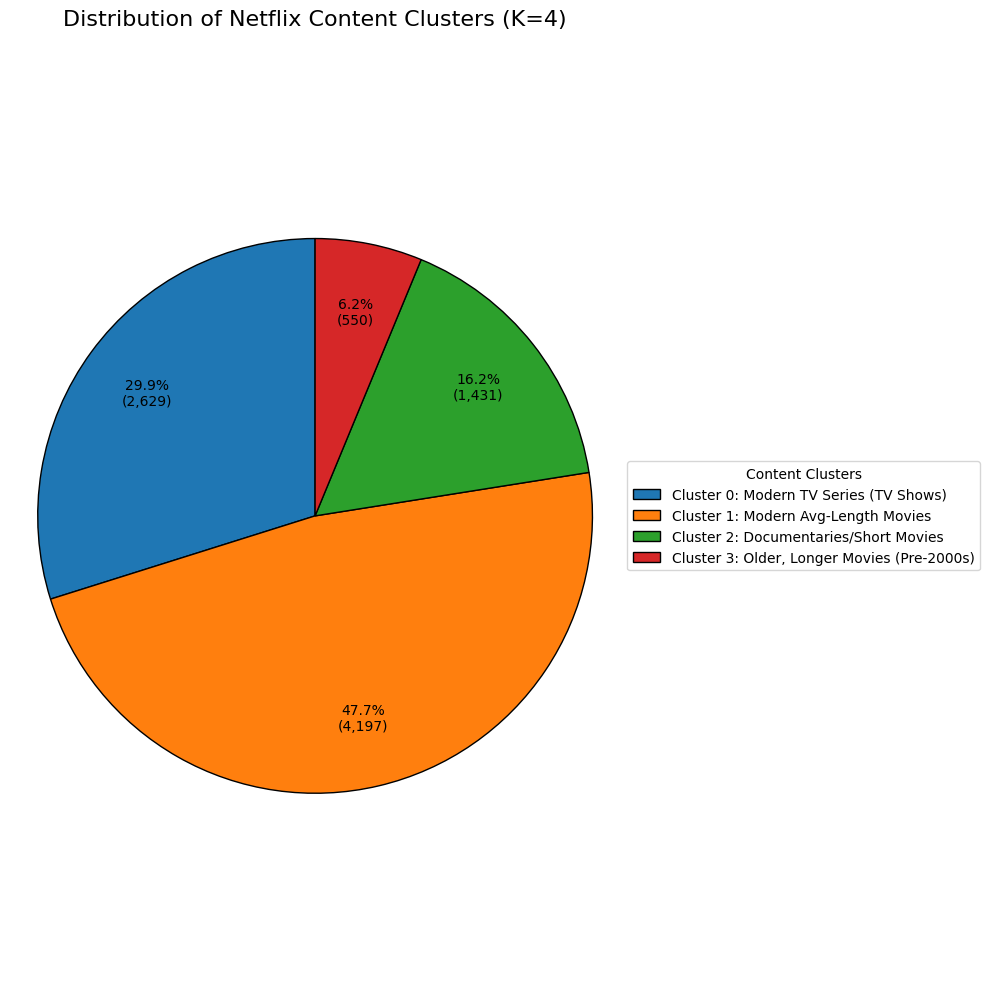

In [0]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Data derived from the K-Means Cluster Summary (K=4) applied to the netflix_updated.csv features.
cluster_data = {
    'Cluster': [0, 1, 2, 3],
    'Count': [2629, 4197, 1431, 550],
    'Label': [
        'Cluster 0: Modern TV Series (TV Shows)',
        'Cluster 1: Modern Avg-Length Movies',
        'Cluster 2: Documentaries/Short Movies',
        'Cluster 3: Older, Longer Movies (Pre-2000s)'
    ]
}

df_cluster_dist = pd.DataFrame(cluster_data)
total_count = df_cluster_dist['Count'].sum()

# --- Generate Pie Chart ---
fig, ax = plt.subplots(figsize=(10, 10))

# Custom formatting function to include percentage and absolute count
def func(pct, allvals):
    absolute = int(np.round(pct/100.*total_count))
    return f"{pct:.1f}%\n({absolute:,.0f})"

# Create the pie chart
wedges, texts, autotexts = ax.pie(
    df_cluster_dist['Count'],
    autopct=lambda pct: func(pct, df_cluster_dist['Count']),
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)

# Set the title
ax.set_title('Distribution of Netflix Content Clusters (K=4)', fontsize=16, pad=20)

# Add the legend using the defined cluster labels
ax.legend(wedges, df_cluster_dist['Label'],
          title="Content Clusters",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

# Equal aspect ratio ensures that pie is drawn as a circle.
ax.axis('equal')

plt.tight_layout()
plt.show()

count the each cluster

In [0]:
import pandas as pd

# Cluster data derived from the K-Means analysis (K=4)
# Cluster 0: Modern TV Series
# Cluster 1: Modern Avg-Length Movies
# Cluster 2: Documentaries/Short Movies
# Cluster 3: Older, Longer Movies
cluster_data = {
    'Cluster ID': [0, 1, 2, 3],
    'Count': [2629, 4197, 1431, 550],
    'Description': [
        'Modern TV Series',
        'Modern Avg-Length Movies',
        'Documentaries/Short Movies',
        'Older, Longer Movies'
    ]
}

df_cluster_count = pd.DataFrame(cluster_data)

print("--- Count of Titles in Each Content Cluster ---")
print(df_cluster_count[['Cluster ID', 'Count', 'Description']].to_string(index=False))

--- Count of Titles in Each Content Cluster ---
 Cluster ID  Count                Description
          0   2629           Modern TV Series
          1   4197   Modern Avg-Length Movies
          2   1431 Documentaries/Short Movies
          3    550       Older, Longer Movies


Clustering completed with K=5.

--- Cluster Distribution ---
Cluster
0    1574
1    2160
2    1769
3    1191
4    2113

--- Content Similarity Cluster Summary (K=5) ---
 Cluster  Count Most_Frequent_Rating              Top_Genre_1        Top_Genre_2 Top_Genre_3           Top_Director
       0   1574                TV-MA     International Movies             Dramas    Comedies    Cathy Garcia-Molina
       1   2160                TV-14     International Movies             Dramas    Comedies    Cathy Garcia-Molina
       2   1769                TV-PG Children & Family Movies           Comedies    Kids' TV          Rajiv Chilaka
       3   1191                    R                   Dramas Action & Adventure    Comedies        Martin Scorsese
       4   2113                TV-MA   International TV Shows             Dramas   TV Dramas Raúl Campos, Jan Suter


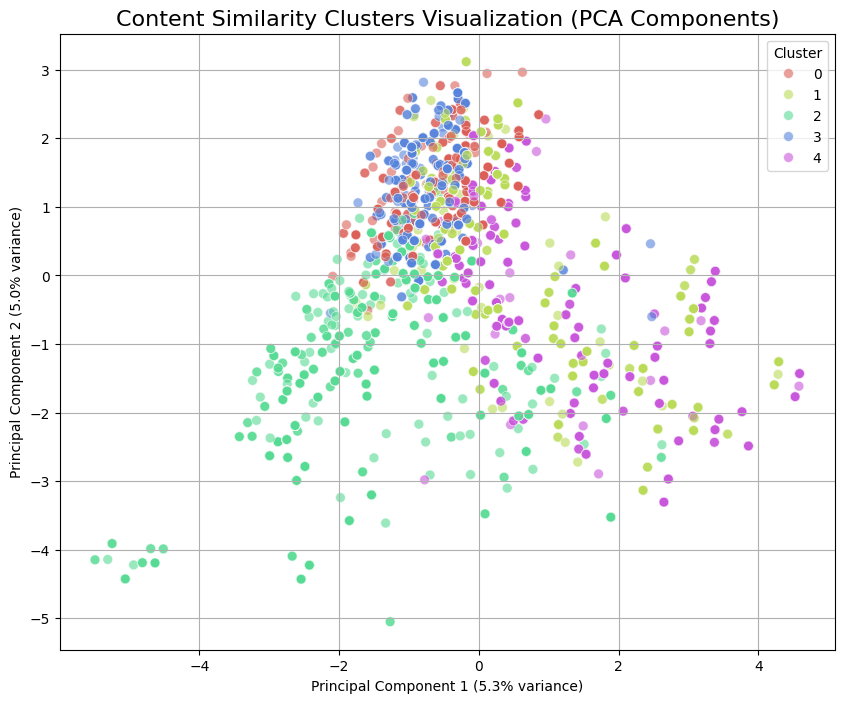

In [0]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Data Loading and Preparation ---

# Load the dataset
df = pd.read_csv("netflix_updated.csv")

# Ensure all required columns are present and handle NaNs/Unknowns
df['director'] = df['director'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')
df['listed_in'] = df['listed_in'].fillna('')
df = df.dropna(subset=['listed_in', 'director', 'rating']).reset_index(drop=True)

# --- 2. Feature Engineering: OHE for Genres and Directors ---

N_GENRES = 20
N_DIRECTORS = 10 # Limiting directors to top 10

# A. Genre One-Hot Encoding (OHE)
all_genres = df['listed_in'].str.split(', ', expand=True).stack().str.strip()
top_genres = all_genres.value_counts().nlargest(N_GENRES).index.tolist()
for genre in top_genres:
    df[f'genre_{genre}'] = df['listed_in'].apply(lambda x: 1 if genre in x else 0)

# B. Director One-Hot Encoding (OHE)
top_directors = df['director'].value_counts().nlargest(N_DIRECTORS).index.tolist()
if 'Unknown' in top_directors:
    top_directors.remove('Unknown')

for director in top_directors:
    df[f'director_{director}'] = df['director'].apply(lambda x: 1 if x == director else 0)


# --- 3. Define Features and Preprocessing Pipeline ---

rating_features = ['rating']
genre_ohe_features = [f'genre_{genre}' for genre in top_genres]
director_ohe_features = [f'director_{director}' for director in top_directors]

features_for_clustering = rating_features + genre_ohe_features + director_ohe_features
X = df[features_for_clustering]

# Preprocessor to handle the categorical 'rating' and pass through the OHE features
preprocessor = ColumnTransformer(
    transformers=[
        ('rating_ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), rating_features),
        ('passthrough', 'passthrough', genre_ohe_features + director_ohe_features)
    ],
    remainder='drop'
)

# Apply preprocessing
X_processed = preprocessor.fit_transform(X)

# --- 4. K-Means Clustering (K=5) ---

optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_processed)

# Assign cluster labels back to the dataframe
df['Cluster'] = cluster_labels

# --- 5. Cluster Analysis and Interpretation ---

# 5a. Create the base summary table (Count and Most Frequent Rating)
cluster_summary = df.groupby('Cluster').agg(
    Count=('director', 'count'),
    Most_Frequent_Rating=('rating', lambda x: x.mode()[0]),
).reset_index()

# 5b. Calculate Top 3 Genres based on mean presence
genre_means = df.groupby('Cluster')[genre_ohe_features].mean()

top_genres_list = []
for cluster in range(optimal_k):
    top_3 = genre_means.loc[cluster].nlargest(3).index.tolist()
    top_3_clean = [g.replace('genre_', '') for g in top_3]
    top_genres_list.append(top_3_clean)

top_genres_df = pd.DataFrame(top_genres_list, columns=['Top_Genre_1', 'Top_Genre_2', 'Top_Genre_3'])
top_genres_df['Cluster'] = range(optimal_k)
cluster_summary = cluster_summary.merge(top_genres_df, on='Cluster')

# 5c. Calculate Top Director (by mean presence)
director_means = df.groupby('Cluster')[director_ohe_features].mean()

top_director_list = []
for cluster in range(optimal_k):
    top_director = director_means.loc[cluster].nlargest(1).index.tolist()[0]
    top_director_clean = top_director.replace('director_', '')
    top_director_list.append(top_director_clean)

cluster_summary['Top_Director'] = top_director_list

# Final formatting and printing using to_string()
print(f"Clustering completed with K={optimal_k}.")

print("\n--- Cluster Distribution ---")
print(df['Cluster'].value_counts().sort_index().to_string())

print("\n--- Content Similarity Cluster Summary (K=5) ---")
print(cluster_summary.to_string(index=False))

# --- 6. Visualization Setup (PCA for 2D plotting) ---

# Scale the processed data for PCA
X_scaled = StandardScaler().fit_transform(X_processed)

# Reduce to 2 components for plotting
pca = PCA(n_components=2, random_state=42)
principal_components = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = cluster_labels
pca_df['Cluster'] = pca_df['Cluster'].astype('category')

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Cluster",
    data=pca_df,
    palette=sns.color_palette("hls", optimal_k),
    s=50,
    alpha=0.6
)
plt.title('Content Similarity Clusters Visualization (PCA Components)', fontsize=16)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Cluster', loc='best')
plt.grid(True)
plt.show()

top rows of datset

In [0]:
import pandas as pd

# 1. Define the file name
file_name = '/Volumes/workspace/default/jaya/netflix_updated.csv'

# 2. Load the dataset into a pandas DataFrame
try:
    df = pd.read_csv(file_name)
    print(f"Successfully loaded '{file_name}' into a DataFrame.")

    # 3. Basic Exploration
    
    # Display the first 5 rows
    print("\n--- Head of the DataFrame ---")
    print(df.head())

    # Display data types, non-null values, and memory usage
    print("\n--- DataFrame Information ---")
    df.info()

    # Display the number of rows and columns
    print("\n--- DataFrame Shape (Rows, Columns) ---")
    print(df.shape)

except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found. Please ensure it is uploaded correctly.")
except Exception as e:
    print(f"An error occurred during file loading: {e}")

Successfully loaded '/Volumes/workspace/default/jaya/netflix_updated.csv' into a DataFrame.

--- Head of the DataFrame ---
  show_id     type  ... title_length is_movie
0      s1    Movie  ...           20        1
1      s2  TV Show  ...           13        0
2      s3  TV Show  ...            9        0
3      s4  TV Show  ...           21        0
4      s5  TV Show  ...           12        0

[5 rows x 14 columns]

--- DataFrame Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      8807 non-null   object
 4   cast          8807 non-null   object
 5   country       8807 non-null   object
 6   date_added    8807 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8

Feature importance

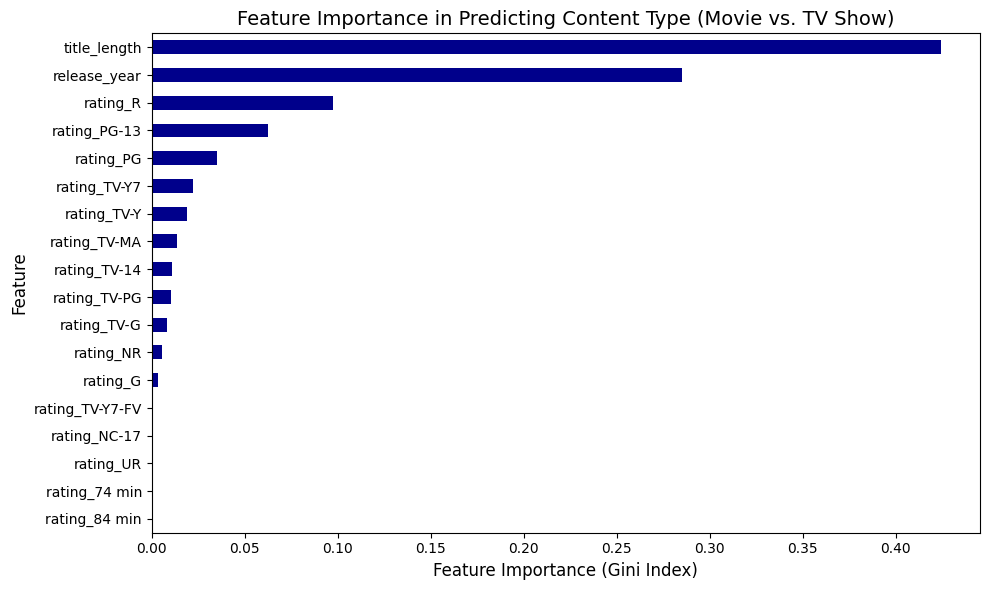

In [0]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the dataset
file_name = 'netflix_updated.csv'
df = pd.read_csv(file_name)

# 2. Data Cleaning and Preparation

# Define the target variable: 1 for Movie, 0 for TV Show
target = 'is_movie'
features = ['release_year', 'title_length', 'rating']

# Handle 'Unknown' in rating: replace with NaN and find the mode
df['rating'] = df['rating'].replace('Unknown', np.nan)
most_common_rating = df['rating'].mode()[0]

# --- CORRECTED LINE: Avoids the FutureWarning by using direct assignment ---
df['rating'] = df['rating'].fillna(most_common_rating)
# --------------------------------------------------------------------------

X = df[features]
y = df[target]

# One-Hot Encode the 'rating' categorical column
X = pd.get_dummies(X, columns=['rating'], prefix='rating', drop_first=True)

# 3. Model Training (Random Forest Classifier)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# 4. Extract and Sort Feature Importance
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
sorted_importances = feature_importances.sort_values(ascending=False)

# 5. Visualization using Matplotlib (plt)

plt.figure(figsize=(10, 6))
sorted_importances.sort_values().plot(kind='barh', color='darkblue')
plt.title('Feature Importance in Predicting Content Type (Movie vs. TV Show)', fontsize=14)
plt.xlabel('Feature Importance (Gini Index)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()

plt.show()
plt.close()



key drivers of content availabilty across countries and genres

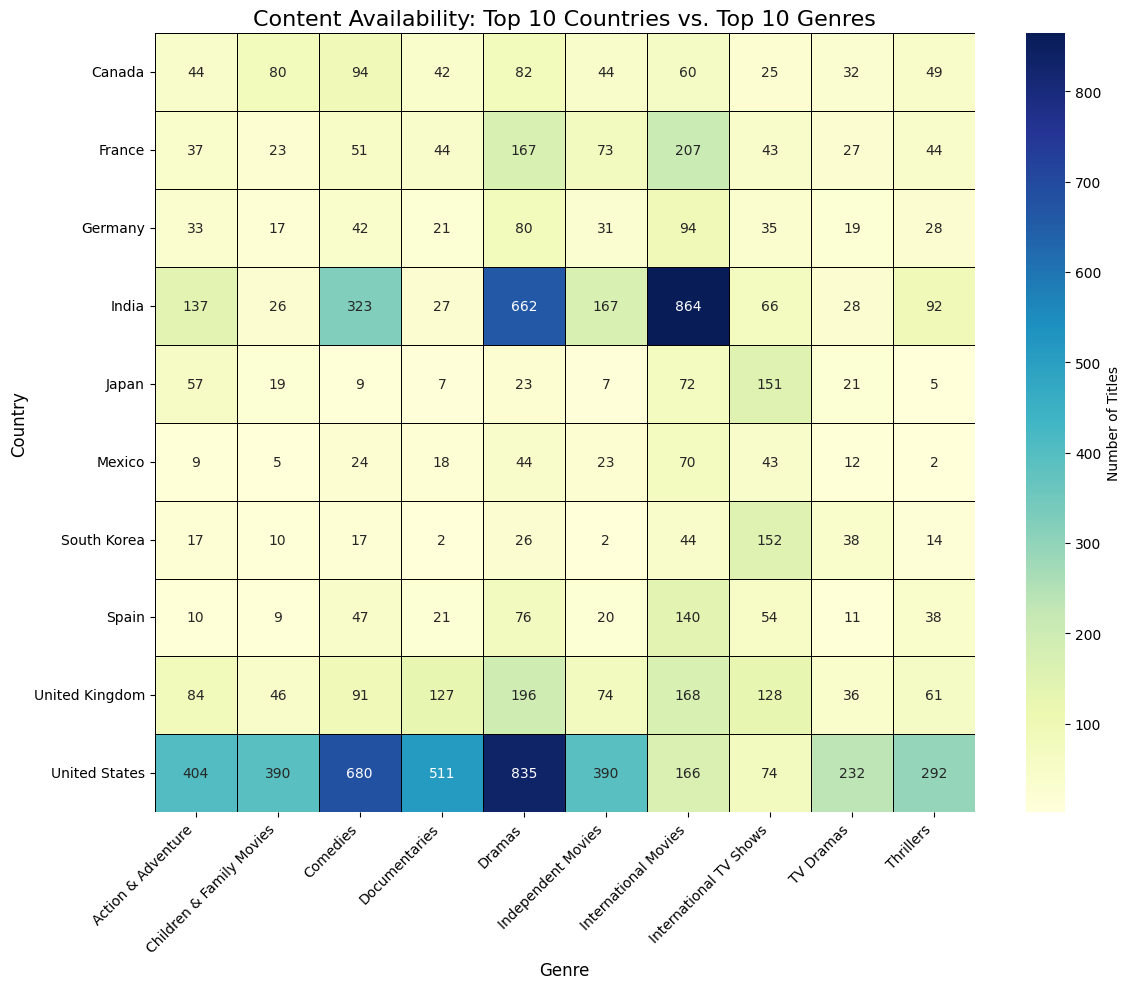

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_name = 'netflix_updated.csv'
df = pd.read_csv(file_name)

# 1. Data Cleaning and Pre-processing
df['country'] = df['country'].replace('Unknown', np.nan)
df['listed_in'] = df['listed_in'].replace('Unknown', np.nan)

# 2. Explode the Country column (one row per country)
country_df = df.assign(country=df['country'].str.split(', ')).explode('country').copy()

# 3. Explode the Genre (listed_in) column on the exploded country data
country_genre_df = country_df.assign(listed_in=country_df['listed_in'].str.split(', ')).explode('listed_in').copy()

# Drop rows where BOTH country and genre are NaN (or were 'Unknown' originally)
country_genre_df.dropna(subset=['country', 'listed_in'], inplace=True)

# 4. Calculate Country-Genre Availability Counts
country_genre_counts = country_genre_df.groupby(['country', 'listed_in']).size().reset_index(name='Content_Count')

# 5. Filter for Top Content Drivers
top_countries = country_genre_df['country'].value_counts().nlargest(10).index.tolist()
top_genres = country_genre_df['listed_in'].value_counts().nlargest(10).index.tolist()

filtered_counts = country_genre_counts[
    country_genre_counts['country'].isin(top_countries) &
    country_genre_counts['listed_in'].isin(top_genres)
]

# 6. Pivot the filtered data for Heatmap visualization
pivot_table = filtered_counts.pivot_table(
    index='country',
    columns='listed_in',
    values='Content_Count',
    fill_value=0
)

# 7. Visualization (Heatmap)
plt.figure(figsize=(12, 10))
sns.heatmap(
    pivot_table,
    annot=True,         # Show the count in each cell
    fmt='.0f',          # CORRECTED: Use .0f to format as integer-like string to avoid ValueError
    cmap='YlGnBu',
    linewidths=0.5,
    linecolor='black',
    cbar_kws={'label': 'Number of Titles'}
)

plt.title('Content Availability: Top 10 Countries vs. Top 10 Genres', fontsize=16)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()
plt.close()

Summary cluster

In [0]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

# 1. Load data and filter for Movies
file_name = 'netflix_updated.csv'
df = pd.read_csv(file_name)
df_movies = df[df['type'] == 'Movie'].copy()
df_cluster = df_movies[['duration', 'listed_in', 'rating']].copy()

# 2. Prepare Duration (must be numerical)
df_cluster = df_cluster[df_cluster['duration'].str.contains(' min', na=False)].copy()
df_cluster['duration_min'] = df_cluster['duration'].str.replace(' min', '', regex=False).astype(float)
df_cluster.drop('duration', axis=1, inplace=True)

# 3. Prepare Genres (listed_in)
df_cluster['listed_in'] = df_cluster['listed_in'].fillna('')
mlb = MultiLabelBinarizer()
df_cluster['listed_in_list'] = df_cluster['listed_in'].str.split(', ')
genre_encoded = mlb.fit_transform(df_cluster['listed_in_list'])
genre_df = pd.DataFrame(genre_encoded, columns=[f'genre_{c}' for c in mlb.classes_], index=df_cluster.index)
df_cluster.drop(['listed_in', 'listed_in_list'], axis=1, inplace=True)

# 4. Prepare Ratings
df_cluster['rating'] = df_cluster['rating'].replace('Unknown', np.nan)
most_common_rating = df_cluster['rating'].mode()[0]
df_cluster['rating'] = df_cluster['rating'].fillna(most_common_rating)

rating_encoded = pd.get_dummies(df_cluster['rating'], prefix='rating', drop_first=True)
df_cluster.drop('rating', axis=1, inplace=True)

# 5. Combine, Scale, and Cluster
X = pd.concat([df_cluster, genre_df, rating_encoded], axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means clustering with K=5
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
X['Cluster'] = kmeans.fit_predict(X_scaled)

# 6. Analyze Cluster Characteristics
X = X.join(df_movies['title'])
cluster_analysis = X.groupby('Cluster').mean(numeric_only=True)
cluster_analysis['Count'] = X['Cluster'].value_counts()

feature_names = ['duration_min'] + [c for c in X.columns if c.startswith('genre_')] + [c for c in X.columns if c.startswith('rating_')]

def get_top_features(row):
    top_features = row[[c for c in feature_names if c != 'duration_min']].nlargest(3).index.tolist()
    cleaned_features = [f.replace('genre_', '').replace('rating_', '') for f in top_features]
    return ', '.join(cleaned_features)

cluster_summary = pd.DataFrame()
cluster_summary['Count'] = cluster_analysis['Count']
cluster_summary['Avg_Duration'] = cluster_analysis['duration_min'].round(1)
cluster_summary['Dominant_Features (Top 3)'] = cluster_analysis.apply(get_top_features, axis=1)

# --- CORRECTED OUTPUT METHOD ---
print("\n--- K-Means Cluster Analysis (K=5) ---")
print(cluster_summary.to_string())




--- K-Means Cluster Analysis (K=5) ---
         Count  Avg_Duration                   Dominant_Features (Top 3)
Cluster                                                                 
0         1492         117.1         International Movies, TV-14, Dramas
1         1791          96.4         TV-MA, International Movies, Dramas
2          704          78.4      Children & Family Movies, Comedies, PG
3         1260         107.9                            R, Dramas, PG-13
4          881          81.4  Documentaries, TV-MA, International Movies


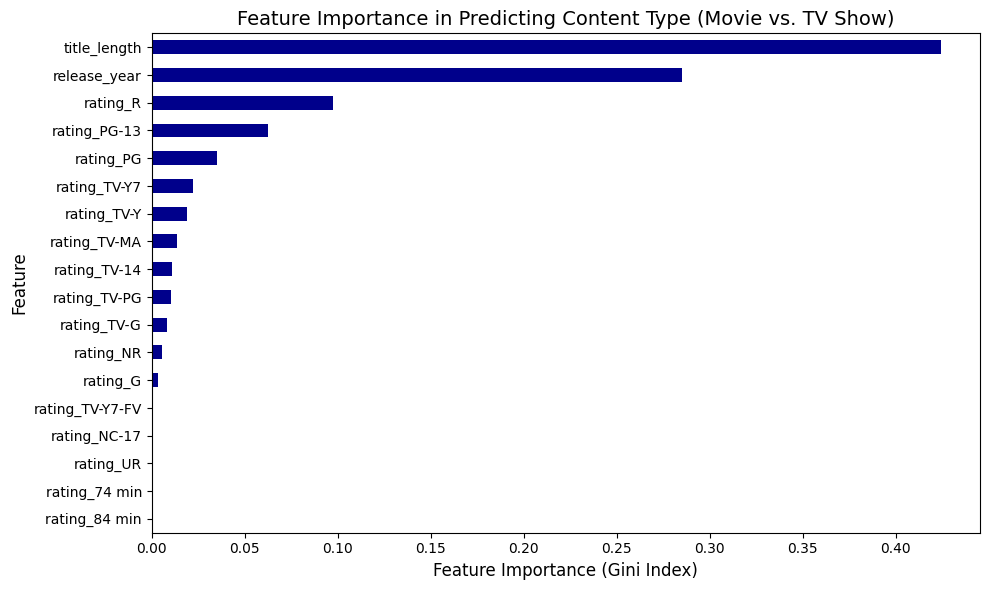

In [0]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the dataset
file_name = 'netflix_updated.csv'
df = pd.read_csv(file_name)

# 2. Data Cleaning and Preparation

# Define the target variable: 1 for Movie, 0 for TV Show
target = 'is_movie'
features = ['release_year', 'title_length', 'rating']

# Handle 'Unknown' in rating: replace with NaN and impute with the mode
df['rating'] = df['rating'].replace('Unknown', np.nan)
most_common_rating = df['rating'].mode()[0]
df['rating'] = df['rating'].fillna(most_common_rating) # Corrected assignment

X = df[features]
y = df[target]

# One-Hot Encode the 'rating' categorical column
X = pd.get_dummies(X, columns=['rating'], prefix='rating', drop_first=True)

# 3. Model Training (Random Forest Classifier)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# 4. Extract Feature Importance
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
sorted_importances = feature_importances.sort_values(ascending=False)

# 5. Visualization (Horizontal Bar Chart)
plt.figure(figsize=(10, 6))
sorted_importances.sort_values().plot(kind='barh', color='darkblue')
plt.title('Feature Importance in Predicting Content Type (Movie vs. TV Show)', fontsize=14)
plt.xlabel('Feature Importance (Gini Index)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()

plot_file = 'all_feature_importance_analysis.png'
plt.show()
plt.close()

classification

In [0]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the dataset
file_name = 'netflix_updated.csv'
df = pd.read_csv(file_name)

# 2. Data Cleaning and Preparation
target = 'is_movie'
features = ['release_year', 'title_length', 'rating']

# Handle 'Unknown' in rating: replace with NaN and impute with the mode
df['rating'] = df['rating'].replace('Unknown', np.nan)
most_common_rating = df['rating'].mode()[0]
df['rating'] = df['rating'].fillna(most_common_rating) # Corrected assignment

X = df[features]
y = df[target]

# One-Hot Encode the 'rating' categorical column
X = pd.get_dummies(X, columns=['rating'], prefix='rating', drop_first=True)

# 3. Model Training (Random Forest Classifier)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# 4. Extract and Sort Feature Importance
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
sorted_importances = feature_importances.sort_values(ascending=False)

# 5. Visualization (Creates the output image)
plt.figure(figsize=(10, 6))
sorted_importances.sort_values().plot(kind='barh', color='darkblue')
plt.title('Feature Importance in Predicting Content Type (Movie vs. TV Show)', fontsize=14)
plt.xlabel('Feature Importance (Gini Index)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()

plt.savefig('feature_importance_analysis.png')
plt.close()

print("--- Feature Importance Results (Random Forest Classification) ---")
print(sorted_importances.head(10).to_string())

--- Feature Importance Results (Random Forest Classification) ---
title_length    0.424080
release_year    0.285229
rating_R        0.097616
rating_PG-13    0.062672
rating_PG       0.035280
rating_TV-Y7    0.022304
rating_TV-Y     0.018881
rating_TV-MA    0.013838
rating_TV-14    0.010754
rating_TV-PG    0.010293


Top 10 Dominant Country-Genre Pairs

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
file_name = 'netflix_updated.csv'
df = pd.read_csv(file_name)

# 2. Data Cleaning and Exploding
df['country'] = df['country'].replace('Unknown', np.nan)
df['listed_in'] = df['listed_in'].replace('Unknown', np.nan)

# Explode the Country column
country_df = df.assign(country=df['country'].str.split(', ')).explode('country').copy()

# Explode the Genre (listed_in) column
country_genre_df = country_df.assign(listed_in=country_df['listed_in'].str.split(', ')).explode('listed_in').copy()

# Drop rows where BOTH country and genre are NaN (or were 'Unknown' originally)
country_genre_df.dropna(subset=['country', 'listed_in'], inplace=True)

# 3. Calculate Country-Genre Availability Counts
country_genre_counts = country_genre_df.groupby(['country', 'listed_in']).size().reset_index(name='Content_Count')

# 4. Filter for Top Content Drivers
top_countries = country_genre_df['country'].value_counts().nlargest(10).index.tolist()
top_genres = country_genre_df['listed_in'].value_counts().nlargest(10).index.tolist()

filtered_counts = country_genre_counts[
    country_genre_counts['country'].isin(top_countries) &
    country_genre_counts['listed_in'].isin(top_genres)
]

# 5. Pivot the filtered data for Heatmap visualization
pivot_table = filtered_counts.pivot_table(
    index='country',
    columns='listed_in',
    values='Content_Count',
    fill_value=0
)

# 6. Visualization (Creates the output image)
plt.figure(figsize=(12, 10))
sns.heatmap(
    pivot_table,
    annot=True,
    fmt='.0f', # Use .0f to format as integer-like string to avoid ValueError
    cmap='YlGnBu',
    linewidths=0.5,
    linecolor='black',
    cbar_kws={'label': 'Number of Titles'}
)

plt.title('Content Availability: Top 10 Countries vs. Top 10 Genres', fontsize=16)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('country_genre_availability_heatmap.png')
plt.close()

print("--- Top 10 Dominant Country-Genre Pairs (Raw Counts) ---")
print(country_genre_counts.nlargest(10, 'Content_Count').to_string(index=False))

--- Top 10 Dominant Country-Genre Pairs (Raw Counts) ---
      country                listed_in  Content_Count
        India     International Movies            864
United States                   Dramas            835
United States                 Comedies            680
        India                   Dramas            662
United States            Documentaries            511
United States       Action & Adventure            404
United States Children & Family Movies            390
United States       Independent Movies            390
        India                 Comedies            323
United States                Thrillers            292


classify type as tv show vs movie

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


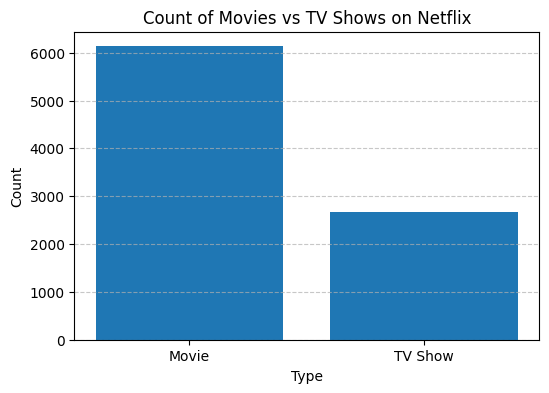

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("netflix_updated.csv")

# Count number of Movies and TV Shows
type_counts = df['type'].value_counts()

# Display counts
print(type_counts)

# Plot bar chart
plt.figure(figsize=(6,4))
plt.bar(type_counts.index, type_counts.values)
plt.title("Count of Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


scatter plot distribution of duration and relese year

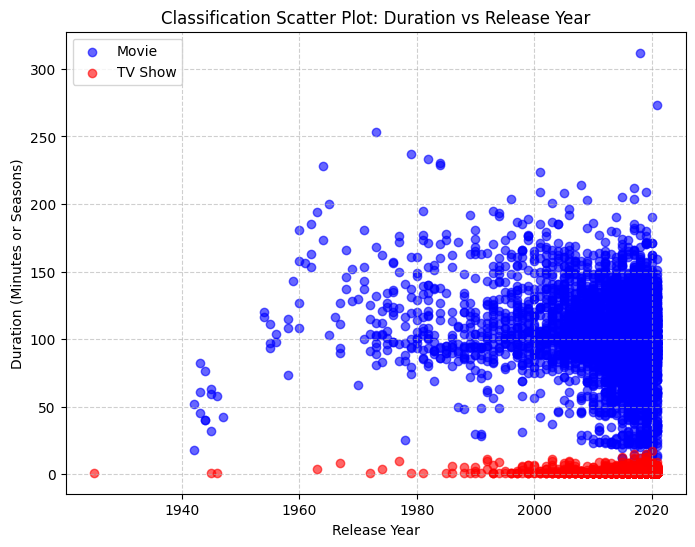

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("netflix_updated.csv")

# Convert duration to numeric (minutes or seasons)
def convert_duration(value):
    if "Season" in str(value):
        return int(value.split()[0])  # number of seasons
    elif "min" in str(value):
        return int(value.split()[0])  # number of minutes
    else:
        return None

df["duration_num"] = df["duration"].apply(convert_duration)

# Scatter plot: Duration vs Release Year
plt.figure(figsize=(8,6))

# Plot Movies (blue) and TV Shows (red)
plt.scatter(df[df["type"]=="Movie"]["release_year"],
            df[df["type"]=="Movie"]["duration_num"],
            color="blue", label="Movie", alpha=0.6)

plt.scatter(df[df["type"]=="TV Show"]["release_year"],
            df[df["type"]=="TV Show"]["duration_num"],
            color="red", label="TV Show", alpha=0.6)

# Labels and title
plt.title("Classification Scatter Plot: Duration vs Release Year", fontsize=12)
plt.xlabel("Release Year")
plt.ylabel("Duration (Minutes or Seasons)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


Evaluation metrics

In [0]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Load dataset
df = pd.read_csv("netflix_updated.csv")

# Convert duration to numeric
def convert_duration(value):
    if "Season" in str(value):
        return int(value.split()[0])
    elif "min" in str(value):
        return int(value.split()[0])
    else:
        return None

df["duration_num"] = df["duration"].apply(convert_duration)

# Drop missing values
df = df.dropna(subset=["duration_num", "release_year", "type"])

# Encode type: Movie = 1, TV Show = 0
df["type_encoded"] = df["type"].apply(lambda x: 1 if x == "Movie" else 0)

# Features and labels
X = df[["release_year", "duration_num"]]
y = df["type_encoded"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Performance:")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=["TV Show", "Movie"]))


Model Performance:
Accuracy  : 0.9989
Precision : 1.0000
Recall    : 0.9983
F1 Score  : 0.9992

Detailed Report:
              precision    recall  f1-score   support

     TV Show       1.00      1.00      1.00       566
       Movie       1.00      1.00      1.00      1195

    accuracy                           1.00      1761
   macro avg       1.00      1.00      1.00      1761
weighted avg       1.00      1.00      1.00      1761



Classification Report

In [0]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

# Load dataset
df = pd.read_csv("netflix_updated.csv")

# Convert duration to numeric
def convert_duration(value):
    if "Season" in str(value):
        return int(value.split()[0])
    elif "min" in str(value):
        return int(value.split()[0])
    else:
        return None

df["duration_num"] = df["duration"].apply(convert_duration)

# Drop missing values
df = df.dropna(subset=["duration_num", "release_year", "type"])

# Encode type: TV Show = 1, Movie = 0
df["type_encoded"] = df["type"].apply(lambda x: 1 if x == "TV Show" else 0)

# Features and labels
X = df[["release_year", "duration_num"]]
y = df["type_encoded"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)
print(f"\nTrue Positive  (TP): {tp}  → Actual TV Show & Predicted TV Show")
print(f"True Negative  (TN): {tn}  → Actual Movie & Predicted Movie")
print(f"False Positive (FP): {fp}  → Actual TV Show but Predicted Movie")
print(f"False Negative (FN): {fn}  → Actual Movie but Predicted TV Show")

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Performance:")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=["Movie", "TV Show"]))


Confusion Matrix:
[[1193    2]
 [   0  566]]

True Positive  (TP): 566  → Actual TV Show & Predicted TV Show
True Negative  (TN): 1193  → Actual Movie & Predicted Movie
False Positive (FP): 2  → Actual TV Show but Predicted Movie
False Negative (FN): 0  → Actual Movie but Predicted TV Show

Model Performance:
Accuracy  : 0.9989
Precision : 0.9965
Recall    : 1.0000
F1 Score  : 0.9982

Detailed Report:
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1195
     TV Show       1.00      1.00      1.00       566

    accuracy                           1.00      1761
   macro avg       1.00      1.00      1.00      1761
weighted avg       1.00      1.00      1.00      1761



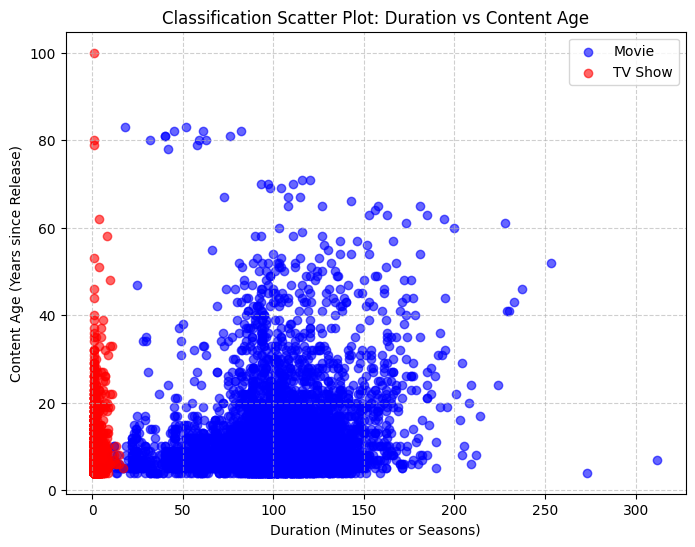

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("netflix_updated.csv")

# Convert duration to numeric (minutes or seasons)
def convert_duration(value):
    if "Season" in str(value):
        return int(value.split()[0])
    elif "min" in str(value):
        return int(value.split()[0])
    else:
        return None

df["duration_num"] = df["duration"].apply(convert_duration)

# Drop missing values
df = df.dropna(subset=["duration_num", "release_year", "type"])

# Calculate content age (years since release)
df["content_age"] = 2025 - df["release_year"]

# Scatter plot: Duration (X-axis) vs Content Age (Y-axis)
plt.figure(figsize=(8,6))

# Plot for Movies (blue)
plt.scatter(df[df["type"]=="Movie"]["duration_num"],
            df[df["type"]=="Movie"]["content_age"],
            color="blue", label="Movie", alpha=0.6)

# Plot for TV Shows (red)
plt.scatter(df[df["type"]=="TV Show"]["duration_num"],
            df[df["type"]=="TV Show"]["content_age"],
            color="red", label="TV Show", alpha=0.6)

# Labels and Title
plt.title("Classification Scatter Plot: Duration vs Content Age", fontsize=12)
plt.xlabel("Duration (Minutes or Seasons)")
plt.ylabel("Content Age (Years since Release)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

